# 2.10: Comparativa y Casos de Uso

## 7.1 Tabla comparativa

| Criterio | Matplotlib | Seaborn | Plotly |
|---|---|---|---|
| Velocidad de código | Lenta | Rápida | Rápida (px) / Media (go) |
| Control estético | Total | Limitado | Total |
| Interactividad | No | No | Sí |
| Gráficos estadísticos | Manual | Nativos | Algunos |
| 3D | Básico | No | Completo |
| Integración Pandas | Manual | Nativa | Nativa |
| Publicaciones científicas | Excelente | Buena | Limitada |
| Web/Dashboards | No | No | Excelente |

## 7.2 Guía de decisión

```
¿Necesitas interactividad?
├── SÍ  → PLOTLY
└── NO  → ¿Para publicación científica?
          ├── SÍ  → MATPLOTLIB
          └── NO  → ¿Gráfico estadístico rápido?
                    ├── SÍ  → SEABORN
                    └── NO  → MATPLOTLIB
```

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import numpy as np

tips = sns.load_dataset('tips')
print('El MISMO gráfico con las tres bibliotecas:')

El MISMO gráfico con las tres bibliotecas:


## 7.3 Con Matplotlib

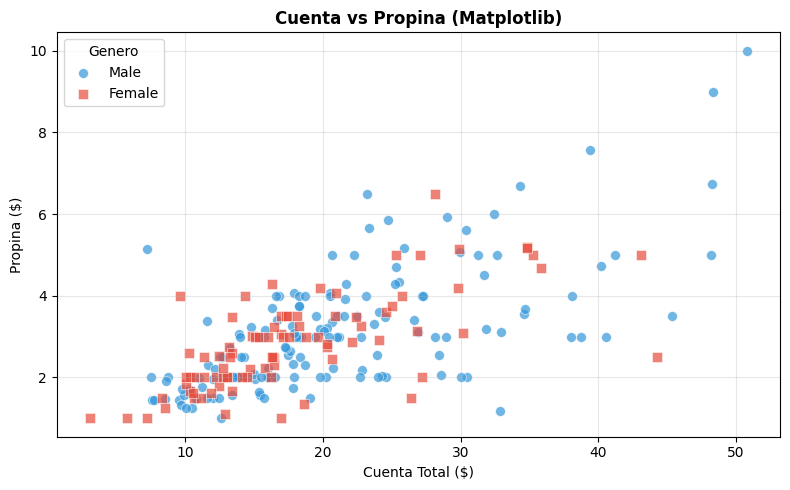

Matplotlib: 12 lineas, estatico, control total


In [2]:
# MATPLOTLIB — máximo control, más código
fig, ax = plt.subplots(figsize=(8, 5))

for sexo, color, marcador in [('Male','#3498DB','o'),('Female','#E74C3C','s')]:
    mask = tips['sex'] == sexo
    ax.scatter(tips.loc[mask,'total_bill'], tips.loc[mask,'tip'],
               c=color, marker=marcador, s=50, alpha=0.7,
               label=sexo, edgecolors='white', linewidths=0.5)

ax.set_title('Cuenta vs Propina (Matplotlib)', fontweight='bold', fontsize=12)
ax.set_xlabel('Cuenta Total ($)')
ax.set_ylabel('Propina ($)')
ax.legend(title='Genero')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Matplotlib: 12 lineas, estatico, control total')

## 7.4 Con Seaborn

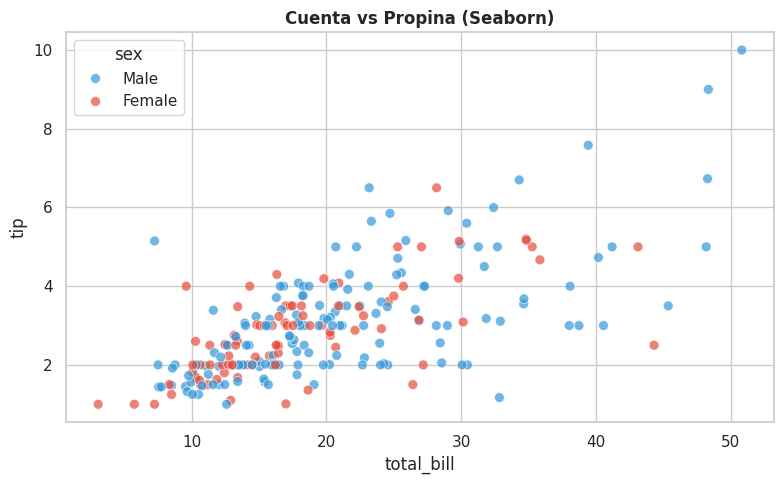

Seaborn: 5 lineas, estatico, integracion Pandas


In [3]:
# SEABORN — rápido y elegante
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex',
                palette={'Male':'#3498DB','Female':'#E74C3C'},
                alpha=0.7, s=50, ax=ax)
ax.set_title('Cuenta vs Propina (Seaborn)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()
print('Seaborn: 5 lineas, estatico, integracion Pandas')

## 7.5 Con Plotly

In [4]:
# PLOTLY — interactivo con pocas líneas
fig = px.scatter(
    tips, x='total_bill', y='tip', color='sex',
    color_discrete_map={'Male':'#3498DB','Female':'#E74C3C'},
    title='Cuenta vs Propina (Plotly)',
    labels={'total_bill':'Cuenta Total ($)','tip':'Propina ($)','sex':'Genero'},
    template='plotly_white',
    hover_data=['day','time','size'], opacity=0.7)
fig.show()
print('Plotly: 6 lineas, interactivo (zoom, tooltips, filtros)')

Plotly: 6 lineas, interactivo (zoom, tooltips, filtros)


## 7.6 Referencia rápida

### Matplotlib
| Función | Qué hace |
|---|---|
| `plt.plot(x, y)` | Líneas |
| `plt.scatter(x, y)` | Puntos |
| `plt.bar(x, h)` | Barras verticales |
| `plt.barh(y, w)` | Barras horizontales |
| `plt.hist(x, bins)` | Histograma |
| `plt.pie(sizes)` | Pastel |
| `plt.boxplot(data)` | Caja y bigotes |
| `plt.imshow(m)` | Imagen/heatmap |
| `plt.subplots(r,c)` | Cuadrícula de ejes |
| `plt.tight_layout()` | Ajustar márgenes |
| `plt.savefig('f')` | Guardar figura |
| `plt.axvline(x=v)` | Línea vertical |
| `plt.axhline(y=v)` | Línea horizontal |
| `plt.annotate(t,xy)` | Anotación con flecha |

### Seaborn
| Función | Qué hace |
|---|---|
| `sns.scatterplot()` | Scatter con hue/size |
| `sns.lineplot()` | Línea con IC automático |
| `sns.histplot()` | Histograma mejorado |
| `sns.kdeplot()` | Curva de densidad |
| `sns.boxplot()` | Caja y bigotes |
| `sns.violinplot()` | Violín (KDE+box) |
| `sns.barplot()` | Media con IC |
| `sns.heatmap()` | Mapa de calor |
| `sns.pairplot()` | Matriz de dispersión |
| `sns.regplot()` | Regresión lineal |
| `sns.FacetGrid()` | Cuadrícula por categorías |
| `sns.despine()` | Quitar bordes |

### Plotly Express
| Función | Qué hace |
|---|---|
| `px.scatter()` | Scatter interactivo |
| `px.line()` | Línea interactiva |
| `px.bar()` | Barras interactivas |
| `px.histogram()` | Histograma interactivo |
| `px.box()` | Boxplot interactivo |
| `px.scatter_3d()` | Scatter 3D |
| `px.choropleth()` | Mapa coroplético |
| `px.treemap()` | Treemap |
| `px.sunburst()` | Sunburst |
| `fig.write_html()` | Exportar HTML |
| `fig.write_image()` | Exportar PNG/PDF |

## 7.7 Flujo de trabajo recomendado

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      333.000000     333.000000         333.000000   333.000000
mean        43.992793      17.164865         200.966967  4207.057057
std          5.468668       1.969235          14.015765   805.215802
min         32.100000      13.100000         172.000000  2700.000000
25%         39.500000      15.600000         190.000000  3550.000000
50%         44.500000      17.300000         197.000000  4050.000000
75%         48.600000      18.700000         213.000000  4775.000000
max         59.600000      21.500000         231.000000  6300.000000


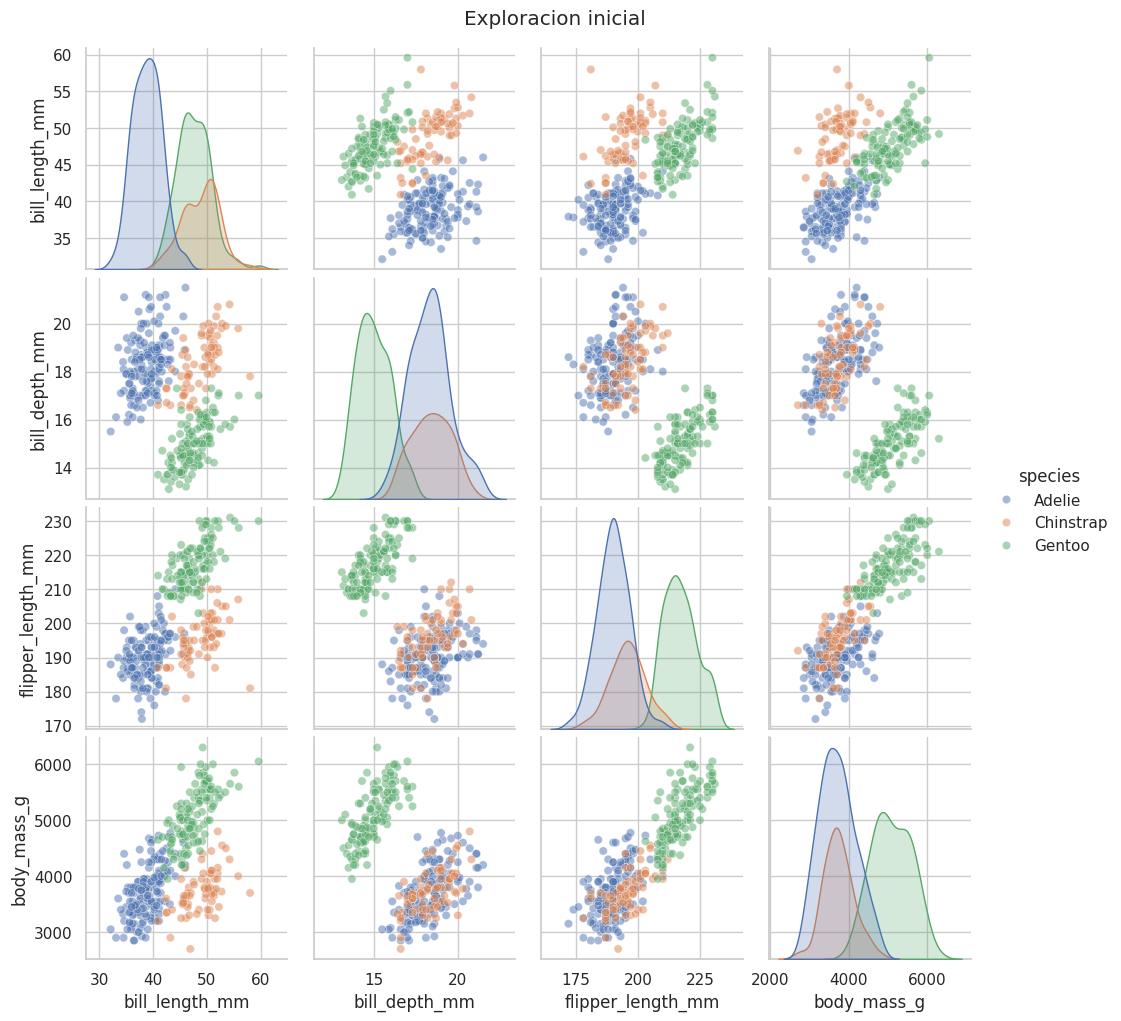

2 lineas = vision completa de los datos


In [5]:
# PASO 1: Exploración rápida con Seaborn
import seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style='whitegrid')
df = sns.load_dataset('penguins').dropna()
print(df.describe())

sns.pairplot(df, hue='species', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Exploracion inicial', y=1.02)
plt.show()
print('2 lineas = vision completa de los datos')

In [6]:
# PASO 2: Analisis interactivo con Plotly
import plotly.express as px
df = px.data.iris()
fig = px.scatter_matrix(
    df,
    dimensions=['sepal_length','sepal_width','petal_length','petal_width'],
    color='species', title='Matriz interactiva',
    template='plotly_white')
fig.update_traces(diagonal_visible=False)
fig.show()
print('Click en la leyenda para filtrar especies')

Click en la leyenda para filtrar especies


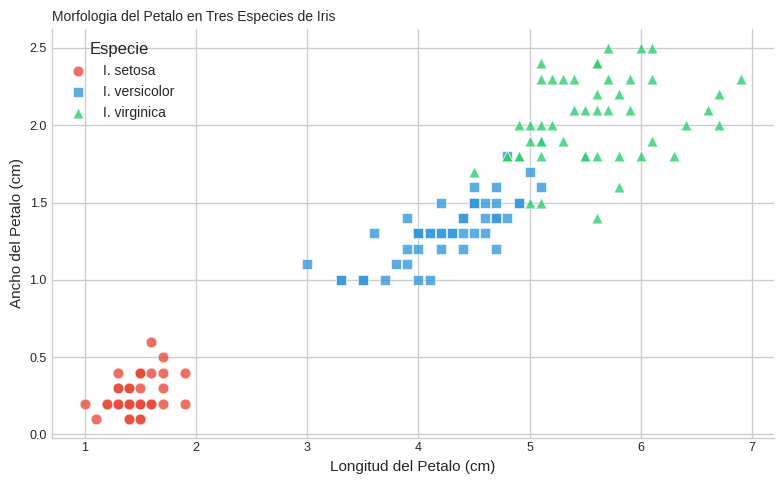

Listo para publicar en revistas cientificas


In [7]:
# PASO 3: Grafico final para publicacion con Matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_iris = sns.load_dataset('iris')
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

cols = {'setosa':'#E74C3C','versicolor':'#3498DB','virginica':'#2ECC71'}
mrks = {'setosa':'o','versicolor':'s','virginica':'^'}

for esp in df_iris['species'].unique():
    mask = df_iris['species'] == esp
    ax.scatter(df_iris.loc[mask,'petal_length'], df_iris.loc[mask,'petal_width'],
               c=cols[esp], marker=mrks[esp], s=60, alpha=0.8,
               edgecolors='white', linewidths=0.5, label=f'I. {esp}')

ax.set_xlabel('Longitud del Petalo (cm)', fontsize=11)
ax.set_ylabel('Ancho del Petalo (cm)', fontsize=11)
ax.set_title('Morfologia del Petalo en Tres Especies de Iris', fontsize=10, loc='left')
ax.legend(title='Especie', framealpha=0.9, fontsize=10)

for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
ax.tick_params(labelsize=9)

plt.tight_layout()
# plt.savefig('figura.pdf', dpi=300, bbox_inches='tight')
plt.show()
print('Listo para publicar en revistas cientificas')

## Recursos para continuar

| Recurso | URL |
|---|---|
| Documentación Matplotlib | https://matplotlib.org/stable/ |
| Galería Matplotlib | https://matplotlib.org/stable/gallery/ |
| Documentación Seaborn | https://seaborn.pydata.org/ |
| Documentación Plotly | https://plotly.com/python/ |
| Plotly Express | https://plotly.com/python/plotly-express/ |

## Próximos pasos
1. **Plotly Dash** — dashboards web con Python
2. **Bokeh** — alternativa interactiva
3. **Altair** — visualización declarativa
4. **Folium** — mapas interactivos
5. **ydata-profiling** — reportes automáticos de EDA